In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import pickle

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score,
                             roc_auc_score, f1_score, matthews_corrcoef, balanced_accuracy_score)
from sklearn.metrics import average_precision_score, precision_recall_curve, recall_score, precision_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_parquet('new_data_for_ML-tgShifted.parquet')

df = df.sort_values('datetime').reset_index(drop=True)

float_cols = df.select_dtypes(include='float64').columns
df[float_cols] = df[float_cols].astype('float32')
int_cols = df.select_dtypes(include='int64').columns
df[int_cols] = df[int_cols].astype('int32')

print(f"Shape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MG")

Shape: (808940, 231)
Memory: 758.7 MG


In [3]:
for lag in [24, 48, 72, 168]: 
    df[f'alarms_lag_{lag}h'] = (
        df.groupby('region_id')['alarms_last_24h'].shift(lag)
    )

df['alarms_rolling_24h_mean'] = (
    df.groupby('region_id')['alarms_last_24h']
    .transform(lambda x: x.shift(24).rolling(24).mean())
)

df = df.dropna().reset_index(drop=True)

drop_cols = ['datetime', 'alarm', 'city_address', 'city_latitude',
             'city_longitude', 'region', 'season',
             'regions_in_alarm_now', 'alarms_last_24h']

feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols].select_dtypes(include=[np.number])
y = df['alarm']

# train 60% / val 20% / test 20%
val_idx   = int(len(df) * 0.6)
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:val_idx]
X_val   = X.iloc[val_idx:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:val_idx]
y_val   = y.iloc[val_idx:split_idx]
y_test  = y.iloc[split_idx:]

print(f"Train: {X_train.shape}: {df['datetime'].iloc[0]} - {df['datetime'].iloc[val_idx]}")
print(f"Val:   {X_val.shape}: {df['datetime'].iloc[val_idx]} - {df['datetime'].iloc[split_idx]}")
print(f"Test:  {X_test.shape}: {df['datetime'].iloc[split_idx]} - {df['datetime'].iloc[-1]}")

Train: (483045, 227): 2022-03-03 00:00:00 - 2024-07-25 03:00:00
Val:   (161015, 227): 2024-07-25 03:00:00 - 2025-05-16 02:00:00
Test:  (161016, 227): 2025-05-16 02:00:00 - 2026-03-16 23:00:00


In [4]:
tscv = TimeSeriesSplit(n_splits=5)

print("Time Series Cross-Validation:")
print(f"{'Fold':<6} {'Train size':<12} {'Test size':<12} {'ROC-AUC'}")
print("-" * 45)

cv_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_fold_train = X.iloc[train_idx]
    X_fold_val   = X.iloc[val_idx]
    y_fold_train = y.iloc[train_idx]
    y_fold_val   = y.iloc[val_idx]
    
    model_cv = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_fold_train==0).sum()/(y_fold_train==1).sum(),
        eval_metric='aucpr',
        random_state=42, n_jobs=-1
    )
    
    model_cv.fit(X_fold_train, y_fold_train)
    y_prob_cv = model_cv.predict_proba(X_fold_val)[:, 1]
    score = roc_auc_score(y_fold_val, y_prob_cv)
    cv_scores.append(score)
    
    print(f"Fold {fold:<4} {len(train_idx):<12} {len(val_idx):<12} {score:.4f}")

print("-" * 45)
print(f"{'Mean':<18} {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

Time Series Cross-Validation:
Fold   Train size   Test size    ROC-AUC
---------------------------------------------
Fold 1    134181       134179       0.6821
Fold 2    268360       134179       0.7440
Fold 3    402539       134179       0.8045
Fold 4    536718       134179       0.8419
Fold 5    670897       134179       0.8775
---------------------------------------------
Mean               0.7900 ± 0.0697


In [5]:
for lr in [0.01, 0.05, 0.1]:
    model = xgb.XGBClassifier(
        n_estimators=300, max_depth=6,
        learning_rate=lr, subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        eval_metric='aucpr',
        random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_prob_val = model.predict_proba(X_val)[:, 1] 
    print(f"lr={lr} and ROC-AUC: {roc_auc_score(y_val, y_prob_val):.4f}")

lr=0.01 and ROC-AUC: 0.8303
lr=0.05 and ROC-AUC: 0.8301
lr=0.1 and ROC-AUC: 0.8232


In [8]:
model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42, n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [30]:
y_prob_val = model.predict_proba(X_val)[:, 1]


precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob_val)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold (from validation): {best_threshold:.3f}")


X_val_with_meta = X_val.copy()
X_val_with_meta['y_true'] = y_val.values
X_val_with_meta['y_prob'] = y_prob_val
val_start = int(len(df) * 0.6)
X_val_with_meta['region_id'] = df.iloc[val_start:split_idx]['region_id'].values

regional_thresholds = {}
for region in X_val_with_meta['region_id'].unique():
    mask = X_val_with_meta['region_id'] == region
    y_t = X_val_with_meta.loc[mask, 'y_true']
    y_p = X_val_with_meta.loc[mask, 'y_prob']
    
    if y_t.sum() == 0:
        regional_thresholds[region] = 0.35
        continue
    
    best_thresh = 0.05
    for thresh in np.arange(0.50, 0.04, -0.01):
        y_pred = (y_p >= thresh).astype(int)
        r = recall_score(y_t, y_pred, zero_division=0)
        if r >= 0.80:
            best_thresh = round(thresh, 2)
            break
    
    regional_thresholds[region] = best_thresh
    print(f"Region {region}: threshold={best_thresh:.2f}")

y_prob = model.predict_proba(X_test)[:, 1]
MIN_THRESHOLD = 0.25
DEFAULT_THRESHOLD = 0.35

y_pred_final = np.array([
    int(p >= max(regional_thresholds.get(r, DEFAULT_THRESHOLD), MIN_THRESHOLD))
    for p, r in zip(y_prob, df.iloc[split_idx:]['region_id'].values)
])

print("\n Final metrics on the TEST ")
print(classification_report(y_test, y_pred_final, target_names=['No Alarm', 'Alarm']))
print(f"Accuracy:          {accuracy_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC:           {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC:            {average_precision_score(y_test, y_prob):.4f}")
print(f"F1:                {f1_score(y_test, y_pred_final):.4f}")
print(f"MCC:               {matthews_corrcoef(y_test, y_pred_final):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_final):.4f}")

Optimal threshold (from validation): 0.661
Region 4: threshold=0.50
Region 7: threshold=0.13
Region 24: threshold=0.14
Region 11: threshold=0.50
Region 23: threshold=0.50
Region 14: threshold=0.50
Region 10: threshold=0.50
Region 25: threshold=0.50
Region 16: threshold=0.50
Region 6: threshold=0.33
Region 3: threshold=0.13
Region 8: threshold=0.50
Region 13: threshold=0.14
Region 21: threshold=0.50
Region 5: threshold=0.50
Region 2: threshold=0.29
Region 15: threshold=0.35
Region 17: threshold=0.16
Region 19: threshold=0.14
Region 18: threshold=0.50
Region 20: threshold=0.50
Region 22: threshold=0.22
Region 9: threshold=0.14

 Final metrics on the TEST 
              precision    recall  f1-score   support

    No Alarm       0.92      0.59      0.72    114666
       Alarm       0.46      0.87      0.60     46350

    accuracy                           0.67    161016
   macro avg       0.69      0.73      0.66    161016
weighted avg       0.79      0.67      0.69    161016

Accuracy:  

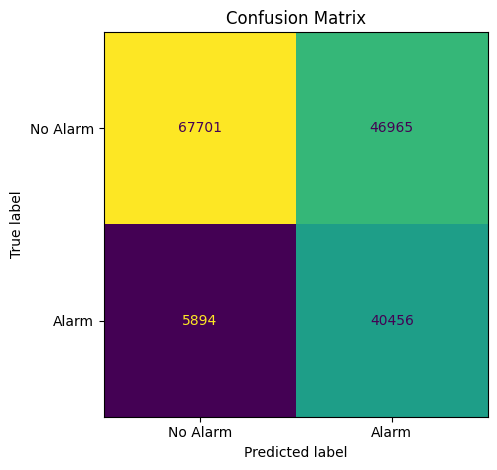

In [21]:
cm = confusion_matrix(y_test, y_pred_final)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Alarm', 'Alarm'])
disp.plot(colorbar=False, values_format='d')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

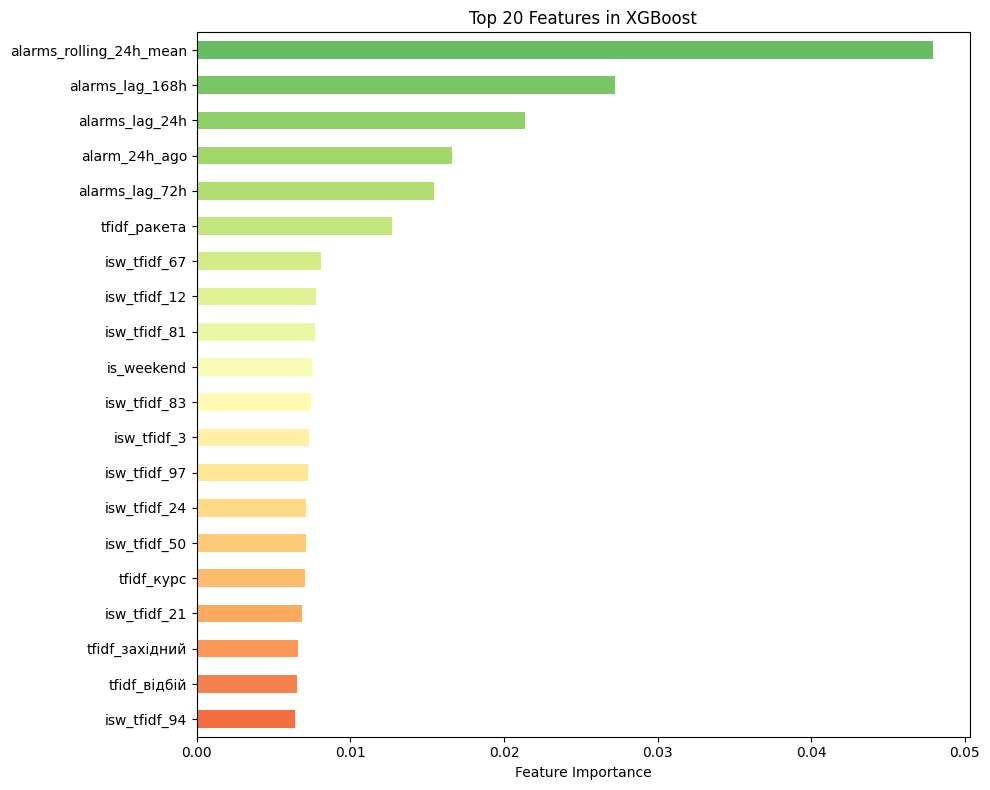

In [29]:
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
top20 = feat_imp.nlargest(20)

plt.figure(figsize=(10, 8))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, 20))
top20.sort_values().plot(kind='barh', color=colors)
plt.title('Top 20 Features in XGBoost')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

In [34]:
X_test.to_csv('test_data.csv', index=False)

In [37]:
with open('6__xgboost__v2.pkl', 'wb') as f:
    pickle.dump({
        'model': model,
        'threshold': 0.35,
        'regional_thresholds': regional_thresholds
    }, f)

In [39]:
import json

with open('6__xgboost__v2.json', 'w') as f:
    json.dump({
        'threshold': 0.35, 
        'regional_thresholds': {int(k): float(v) for k, v in regional_thresholds.items()} 
    }, f, indent=2)